<a href="https://colab.research.google.com/github/joseviniciusfreitastenorio/DialoGPT/blob/main/Categoriza%C3%A7%C3%A3o_Autom%C3%A1tica_de_Despesas_Banc%C3%A1rias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Atualizando as bibliotecas - Instalando Dependências


In [2]:
# Atualizando as bibliotecas principais para garantir compatibilidade e evitar erros
!pip install --upgrade transformers torch pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.0/248.0 MB 1.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cusparselt-cu13
    Found existing installation: nvidia-cusparselt-cu13 0.8.0
    Uninstalling nvidia-cusparselt-cu13-0.8.0:
      Successfully uninstalled nvidia-cusparselt-cu13-0.8.0
  Attempting uninstall: cuda-toolkit
    Found existing installati

Importando as Ferramentas e Baixando o Modelo de IA

In [3]:
# Removemos a biblioteca de visão computacional que está causando a falha
!pip uninstall -y torchvision

# Instalamos apenas o que o nosso projeto de NLP (texto) realmente precisa
!pip install --upgrade transformers torch pandas

Found existing installation: torchvision 0.26.0+cu130
Uninstalling torchvision-0.26.0+cu130:
  Successfully uninstalled torchvision-0.26.0+cu130


In [4]:
from transformers import pipeline
import pandas as pd

# Iniciando o pipeline de Zero-Shot Classification para textos
classificador = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
)

print("Sucesso! Modelo carregado e pronto para categorizar as despesas do banco.")

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


model.safetensors: reconstructing file:   0%|          |  0.00B /  558MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 16.3MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Sucesso! Modelo carregado e pronto para categorizar as despesas do banco.


Preparando os Dados (O Extrato do Cliente)

In [5]:
# Criando uma lista de dicionários com exemplos de compras e pagamentos
dados_extrato = {
    "descricao_fatura": [
        "UBER *TRIP SAO PAULO",
        "PAGAMENTO ENEL CONTA DE LUZ",
        "IFOOD *RESTAURANTE DA MARIA",
        "NETFLIX.COM",
        "POSTO IPIRANGA COMBUSTIVEL",
        "FARMACIA DROGASIL"
    ]
}

# Convertendo a lista para um DataFrame (tabela) do Pandas
df_banco = pd.DataFrame(dados_extrato)

# Exibindo a nossa tabela
print("Dados carregados:")
display(df_banco)

Dados carregados:


,descricao_fatura
0,UBER *TRIP SAO PAULO
1,PAGAMENTO ENEL CONTA DE LUZ
2,IFOOD *RESTAURANTE DA MARIA
3,NETFLIX.COM
4,POSTO IPIRANGA COMBUSTIVEL
5,FARMACIA DROGASIL


Passo 4: Definindo as Categorias e Executando a IA

In [6]:
# 1. Definimos as categorias que o aplicativo mostrará ao cliente
categorias_do_app = ["Transporte", "Contas", "Alimentação", "Lazer", "Saúde"]

# 2. Criamos uma função inteligente para analisar as descrições
def classificar_transacao(texto):
    # O modelo recebe o texto e a lista de categorias possíveis
    resultado = classificador(texto, categorias_do_app)

    # O modelo retorna as categorias ordenadas por probabilidade.
    # Pegamos o primeiro item (índice [0]), que é o "vencedor" com maior certeza.
    categoria_escolhida = resultado['labels'][0]

    return categoria_escolhida

# 3. Aplicamos a nossa função a todas as linhas da coluna 'descricao_fatura'
print("A Inteligência Artificial está lendo e classificando seu extrato. Aguarde...")

# O comando '.apply()' aplica a função em cada linha da tabela automaticamente
df_banco['Categoria_Identificada'] = df_banco['descricao_fatura'].apply(classificar_transacao)

# 4. Mostramos o resultado final maravilhoso!
print("\nClassificação Finalizada!")
display(df_banco)

A Inteligência Artificial está lendo e classificando seu extrato. Aguarde...

Classificação Finalizada!


,descricao_fatura,Categoria_Identificada
0,UBER *TRIP SAO PAULO,Transporte
1,PAGAMENTO ENEL CONTA DE LUZ,Contas
2,IFOOD *RESTAURANTE DA MARIA,Alimentação
3,NETFLIX.COM,Lazer
4,POSTO IPIRANGA COMBUSTIVEL,Contas
5,FARMACIA DROGASIL,Saúde


Visualizando os Gastos (O Dashboard do Cliente)

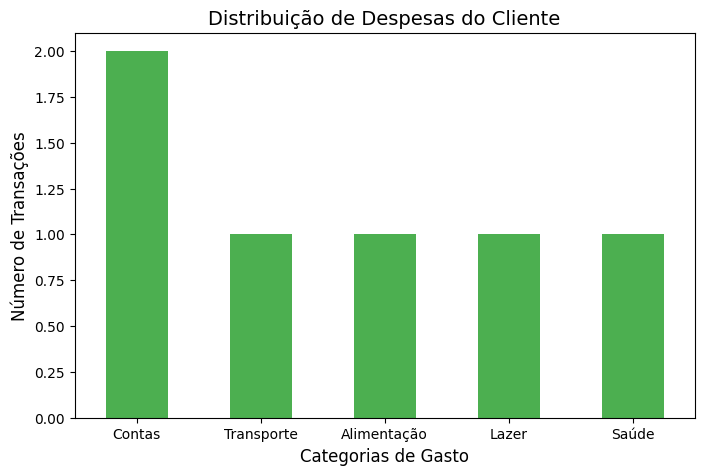

In [7]:
import matplotlib.pyplot as plt

# Contando quantas transações caíram em cada categoria
contagem_categorias = df_banco['Categoria_Identificada'].value_counts()

# Criando um gráfico de barras para o nosso Banco Digital
plt.figure(figsize=(8, 5))
contagem_categorias.plot(kind='bar', color='#4CAF50') # Um verde "banco digital"

# Adicionando títulos e rótulos
plt.title('Distribuição de Despesas do Cliente', fontsize=14)
plt.xlabel('Categorias de Gasto', fontsize=12)
plt.ylabel('Número de Transações', fontsize=12)
plt.xticks(rotation=0) # Mantém os textos na horizontal para facilitar a leitura

# Mostrando o gráfico na tela
plt.show()

Carregando e Limpando a Base de Dados

In [8]:
import pandas as pd

# 1. Carregando o arquivo despesasPorOrgao.csv
# Usamos sep=';' e encoding='latin1' (ou utf-8) porque bases do governo costumam usar esse formato
try:
    df_estudo = pd.read_csv('despesasPorOrgao.csv', sep=';', encoding='latin1')

    # Vamos renomear as colunas para facilitar nossa vida, tirando caracteres estranhos
    df_estudo.columns = ['Mes_Ano', 'Orgao_Superior', 'Orgao_Vinculado', 'Valor_Empenhado', 'Valor_Liquidado', 'Valor_Pago', 'Restos_a_Pagar', 'Coluna_Vazia']

    print("Base de dados carregada com sucesso!")
    display(df_estudo.head())

except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")

Base de dados carregada com sucesso!


,Mes_Ano,Orgao_Superior,Orgao_Vinculado,Valor_Empenhado,Valor_Liquidado,Valor_Pago,Restos_a_Pagar,Coluna_Vazia
0,02/2026,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"60.515.443,20","380.771.877,72","369.567.167,04","39.445.662,17",NaN
1,05/2026,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"47.854.655,31","405.018.203,53","398.942.106,95","11.959.806,32",NaN
2,10/2026,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"- 3.337.059,70","4.094.040,86","259.666.860,25","131.386,58",NaN
3,08/2026,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"71.283.851,52","405.408.048,75","417.328.673,89","7.296.538,40",NaN
4,09/2026,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"54.694.172,91","420.288.465,16","420.114.012,86","1.777.065,46",NaN


Definindo as Categorias do Governo

In [9]:
# Definindo categorias mais adequadas para entidades governamentais
categorias_governo = ["Justiça e Direito", "Educação e Pesquisa", "Saúde", "Defesa e Segurança", "Economia e Finanças", "Meio Ambiente", "Outros"]

def classificar_orgao(texto):
    # Transformando o texto em string por precaução, caso tenha alguma linha vazia
    texto = str(texto)

    resultado = classificador(texto, categorias_governo)
    return resultado['labels'][0]

print("As categorias foram atualizadas para a base de órgãos públicos.")

As categorias foram atualizadas para a base de órgãos públicos.


Executando a IA na Coluna Correta

In [10]:
print("A Inteligência Artificial está analisando os órgãos. Aguarde...")

# Pegando apenas as 20 primeiras linhas para um teste rápido
df_teste = df_estudo.head(20).copy()

# Aplicando a IA na coluna 'Orgao_Superior'
df_teste['Area_Atuacao_IA'] = df_teste['Orgao_Superior'].apply(classificar_orgao)

print("\nClassificação Finalizada!")
# Mostrando apenas a coluna original e a classificação feita pela IA
display(df_teste[['Orgao_Superior', 'Area_Atuacao_IA']])

A Inteligência Artificial está analisando os órgãos. Aguarde...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Classificação Finalizada!


,Orgao_Superior,Area_Atuacao_IA
0,63000 - Advocacia-Geral da UniÃ£o,Defesa e Segurança
1,63000 - Advocacia-Geral da UniÃ£o,Defesa e Segurança
2,63000 - Advocacia-Geral da UniÃ£o,Defesa e Segurança
3,63000 - Advocacia-Geral da UniÃ£o,Defesa e Segurança
4,63000 - Advocacia-Geral da UniÃ£o,Defesa e Segurança
5,63000 - Advocacia-Geral da UniÃ£o,Defesa e Segurança
6,63000 - Advocacia-Geral da UniÃ£o,Defesa e Segurança
7,63000 - Advocacia-Geral da UniÃ£o,Defesa e Segurança
8,63000 - Advocacia-Geral da UniÃ£o,Defesa e Segurança
9,63000 - Advocacia-Geral da UniÃ£o,Defesa e Segurança
